# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

*Estudiantes: Cristóbal Castro Riquelme y Vanessa Meza A.*

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se usarán dos archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

## 1. Exploración inicial del conjunto de entrenamiento.

In [1]:
#Importamos las librerías que vamos a usar
#Librerías para manejar los datos
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Librerías para ML
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.tree import plot_tree

#Librerías para manejar los NaNs
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

#Librerías para manejar las métricas
from sklearn.metrics import mean_squared_error, make_scorer

#Fijamos una semilla para mantener la reproducibilidad
np.random.seed(42)
#Leemos los datos de entrenamiento y prueba
data_train = pd.read_csv("train_redshift.csv")
data_test = pd.read_csv("test_redshift.csv")
data_train.head()

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0,13027624,214.812895,52.987945,1,25.536802,25.462694,25.331811,24.767236,24.867649,24.539227,0,0,-99,1.664840
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0,0,0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0,0,-99,0.297696
3,13039861,215.448870,53.106100,2,24.590983,23.872463,23.713001,23.670067,23.628797,23.663545,0,0,-99,1.159324
4,12004737,214.150124,52.436439,4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,0,0,0,0.811566


In [2]:
#Escribimos las columnas con valores de interés
cols = ["objno_deep2", "ra_deep2", "dec_deep2", "zquality", "u_apercor", "g_apercor", "r_apercor", "i_apercor", "i2_apercor", "z_apercor", "flag_cfhtls", "cfhtls_source", "subaru_source", "zhelio"]
vals_cols= ["u_apercor", "g_apercor", "r_apercor", "i_apercor", "i2_apercor", "z_apercor"]

X = data_train[vals_cols]
Y = data_train["zhelio"].values

In [3]:
#Notamos en el dataset varias columnas que no corresponden precisamente a mediciones del redshift
#por ejemplo, objno_deep2, ra_deep2, dec_deep2, zquality, flag_cfhtls, cfhtls_source y subaru_source.

#Si bien podemos ignorarlas, para limpiar lo más posible los datos podemos interpretarlos. Primero veremos zquality:
print("Zquality values:")
print(data_train["zquality"].value_counts().sort_index())

Zquality values:
zquality
-2      230
-1      144
 0       71
 1     2556
 2     2577
 3     1890
 4    11589
Name: count, dtype: int64


En el paper Zhou et al. (2019) notamos que “zquality” define la calidad del redshift. Por lo que nos interesa filtrar los datos con redshift fiable exigiendo que zquality sea $\geq$ 3, ya que valores reportados como 0/1/2 representan baja confianza, los valores -1 como estrellas y los valores -2 como fallas de medición.

In [4]:
#Ahora analizamos la etiqueta subaru_source
print("subaru_source values:")
print(data_train["subaru_source"].value_counts().sort_index())

subaru_source values:
subaru_source
-99    9266
 0     6937
 1     2854
Name: count, dtype: int64


In [5]:
print("Lista de valores subaru_source por banda:")
for c in vals_cols:
    print(f"{c:12s} -99:{(data_train[c] == -99).sum():4d}  99:{(data_train[c]==99).sum():4d}")

Lista de valores subaru_source por banda:
u_apercor    -99: 439  99: 396
g_apercor    -99: 439  99: 285
r_apercor    -99: 439  99: 282
i_apercor    -99: 439  99: 286
i2_apercor   -99:7230  99: 119
z_apercor    -99: 439  99: 287



`subaru_source` representa la fotometría en la banda Y, donde 0 = deep pointing, 1 = shallow pointing, 99 = no detección y -99 = no observado.
Es por esto que en el filtrado de datos es necesario considerar los valores -99 y 99 como NaNs para no ensuciar la muestra.

## 2. Preparación de los datos para modelamiento.

Considerando los hallazgos del inciso anterior, vamos a reemplazar los subaru_source -99 y 99 por NaN, además de filtrar el set de entrenamiento con un zquality $\geq$ 3 y también buscaremos filtrar valores con zhelio = 0 para descartar mediciones erroneas.

Sin embargo, no aplicaremos esta condición de zquality y zhelio para el set de pruebas, ya que el test no tiene redshift de referencia disponible para poder filtrar.

In [6]:
def clean_data(d):
    d = d.copy()
    for c in vals_cols:
        d[c] = d[c].replace(-99, np.nan)
        d[c] = d[c].replace(99, np.nan)
    return d

data = clean_data(data_train) #Set de entrenamiento
data_test = clean_data(data_test) #Set de prueba

print("train original shape:", data_train.shape)
#Para comprobar que no se han eliminado filas y solo se transformaron los datos en NaNs
print("train cleaned shape:", data.shape)

#Aplicamos el filtro de calidad solo para los datos de entrenamiento
data_clean = data[(data["zquality"] >= 3) & (data["zhelio"] >= 0)].copy()
print ("Tras filtro de calidad:", len(data_clean))

#Filtramos las filas sin banda
mask = data_clean[vals_cols].notna().any(axis=1)
data_clean = data_clean[mask]
print("Tras eliminar filas sin banda fotométrica:", len(data_clean))

print()
print("Faltantes por banda en el set limpio:")
print(data_clean[vals_cols].isna().sum())

train original shape: (19057, 14)
train cleaned shape: (19057, 14)
Tras filtro de calidad: 13475
Tras eliminar filas sin banda fotométrica: 13103

Faltantes por banda en el set limpio:
u_apercor       29
g_apercor        2
r_apercor        0
i_apercor        3
i2_apercor    4666
z_apercor        2
dtype: int64


## 3. Construcción o selección de variables predictoras.

Además de las magnitudes, necesitamos crear las diferencias entre bandas (colores), que en fotometría son las señales que más información traen al respecto del redshift fotométrico.
Además se añade el indicador `missing` en caso de que haya una banda que no coincida con las categorías descritas.

In [7]:
#Debido a que estos datos no están totalmente listos para usarlos en ML, vamos a crear features
def making_features(d):
    d = d.copy()
    for c in vals_cols:
        d[c + "_missing"] = d[c].isna().astype(int)
    d["u-g"] = d["u_apercor"] - d["g_apercor"]
    d["g-r"] = d["g_apercor"] - d["r_apercor"]
    d["r-i"] = d["r_apercor"] - d["i_apercor"]
    d["i-z"] = d["i_apercor"] - d["z_apercor"]
    d["i-i2"] = d["i_apercor"] - d["i2_apercor"]
    return d

data_train = making_features(data_clean)
data_test = making_features(data_test)

features = vals_cols + [c + "_missing" for c in vals_cols] + ["u-g", "g-r", "r-i", "i-z", "i-i2"]
print (f"{len(features)} features:", features)

17 features: ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor', 'u_apercor_missing', 'g_apercor_missing', 'r_apercor_missing', 'i_apercor_missing', 'i2_apercor_missing', 'z_apercor_missing', 'u-g', 'g-r', 'r-i', 'i-z', 'i-i2']


## 4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.

Se realizará un split tipo 80/20 de forma interna.

In [8]:
#Vamos a realizar un split de 80/20.

x = data_train[features]
y = data_train["zhelio"]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)
print ("train:", x_train.shape, "val:", x_val.shape)

train: (10482, 17) val: (2621, 17)


Es importante destacar que ciertos modelos que utilizamos más adelante (Decision Tree, Random Forest, Extra Trees, Gradient Boosting) no soportan NaNs de forma nativa. Al probar sin solucionar esto, recibimos errores que recomendaban la utilización de imputar estos datos para solucionar el problema.

Imputaremos con la mediana solamente en el set de entrenamiento.

In [9]:
imputer = SimpleImputer(strategy="median")
x_train_imp = pd.DataFrame(imputer.fit_transform(x_train), columns=features, index=x_train.index)
x_val_imp = pd.DataFrame(imputer.transform(x_val), columns=features, index=x_val.index)

#Creamos una función para calcular las métricas que nos interesan, MSE (la principal del proyecto),
#además de la mediana y la fracción de galaxias con redshift superior a 0.15
#Así podemos calcularlas para cada algoritmo
def photoz_metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred) #Error cuadrado medio
    dz = (y_true - y_pred) / (1 + y_true) #Diferencia de redshift normalizada (residuo normalizado)
    nmad = 1.48 * np.median(np.abs(dz - np.median(dz))) #Dispersión robusta
    eta = np.mean(np.abs(dz) > 0.15) #Fracción de outliers
    return mse, nmad, eta

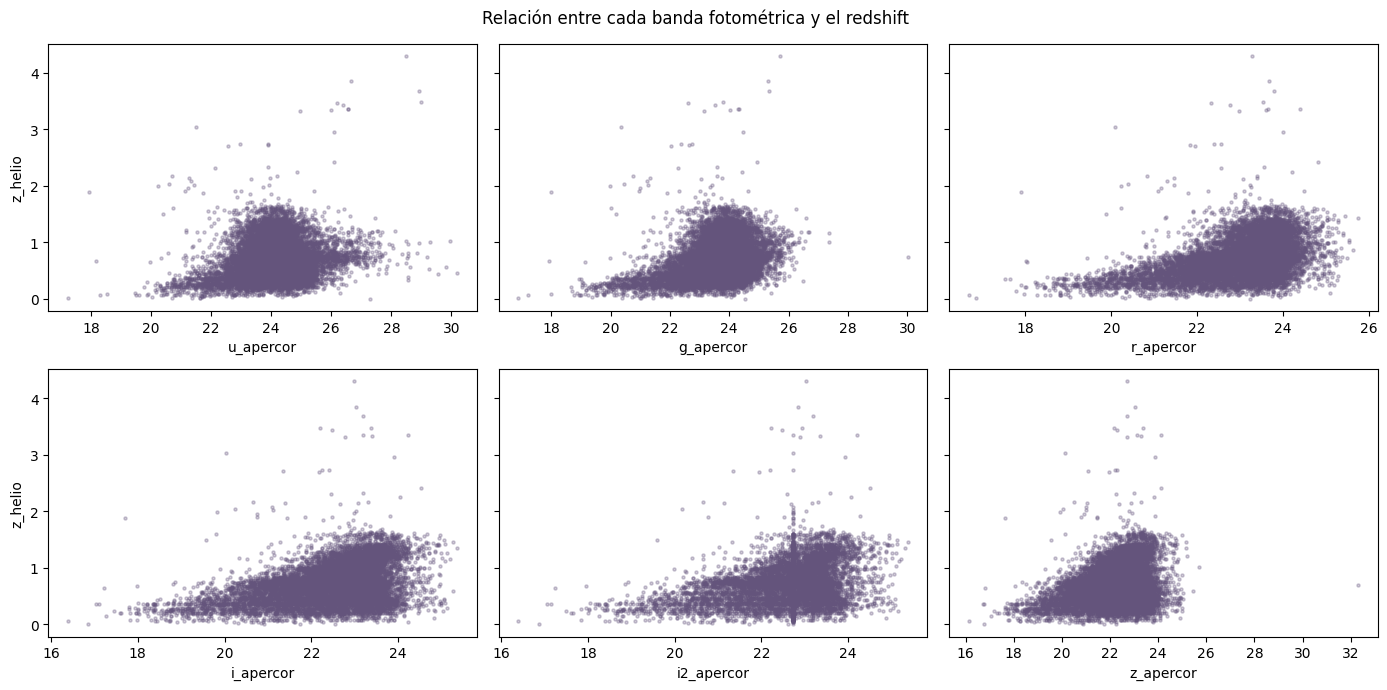

In [10]:
#Visualizamos rápidamente la relación entre bandas y el redshift
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col_name in zip(axes.flat, vals_cols):
    ax.scatter(x_train_imp[col_name], y_train, s=5, alpha=0.3, color = "#64547c")
    ax.set_xlabel(col_name)
axes[0, 0].set_ylabel("z_helio")
axes[1, 0].set_ylabel("z_helio")
plt.suptitle("Relación entre cada banda fotométrica y el redshift")
plt.tight_layout()
plt.show()

## 5. Entrenamiento de un modelo baseline con DecisionTreeRegressor.

Aplicamos el modelo de Árbol de Decisión como modelo base para la futura optimización.

In [11]:
#Comenzamos con el modelo de línea base
model_tree = DecisionTreeRegressor(max_depth = 3, min_samples_leaf = 10, random_state = 42)
model_tree.fit(x_train_imp, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=42)

In [12]:
pred_tr_dt = model_tree.predict(x_train_imp)
pred_val_dt = model_tree.predict(x_val_imp)
mse_tr, nmad_tr, eta_tr = photoz_metrics(y_train, pred_tr_dt)
mse_val, nmad_val, eta_val = photoz_metrics(y_val, pred_val_dt)

print("Decision Tree")
print(f"MSE train: {mse_tr:.5f}, MSE val: {mse_val:.5f}, NMAD val: {nmad_val:.5f}, eta val: {eta_val:.4f}")

Decision Tree
MSE train: 0.05306, MSE val: 0.05343, NMAD val: 0.08934, eta val: 0.1530


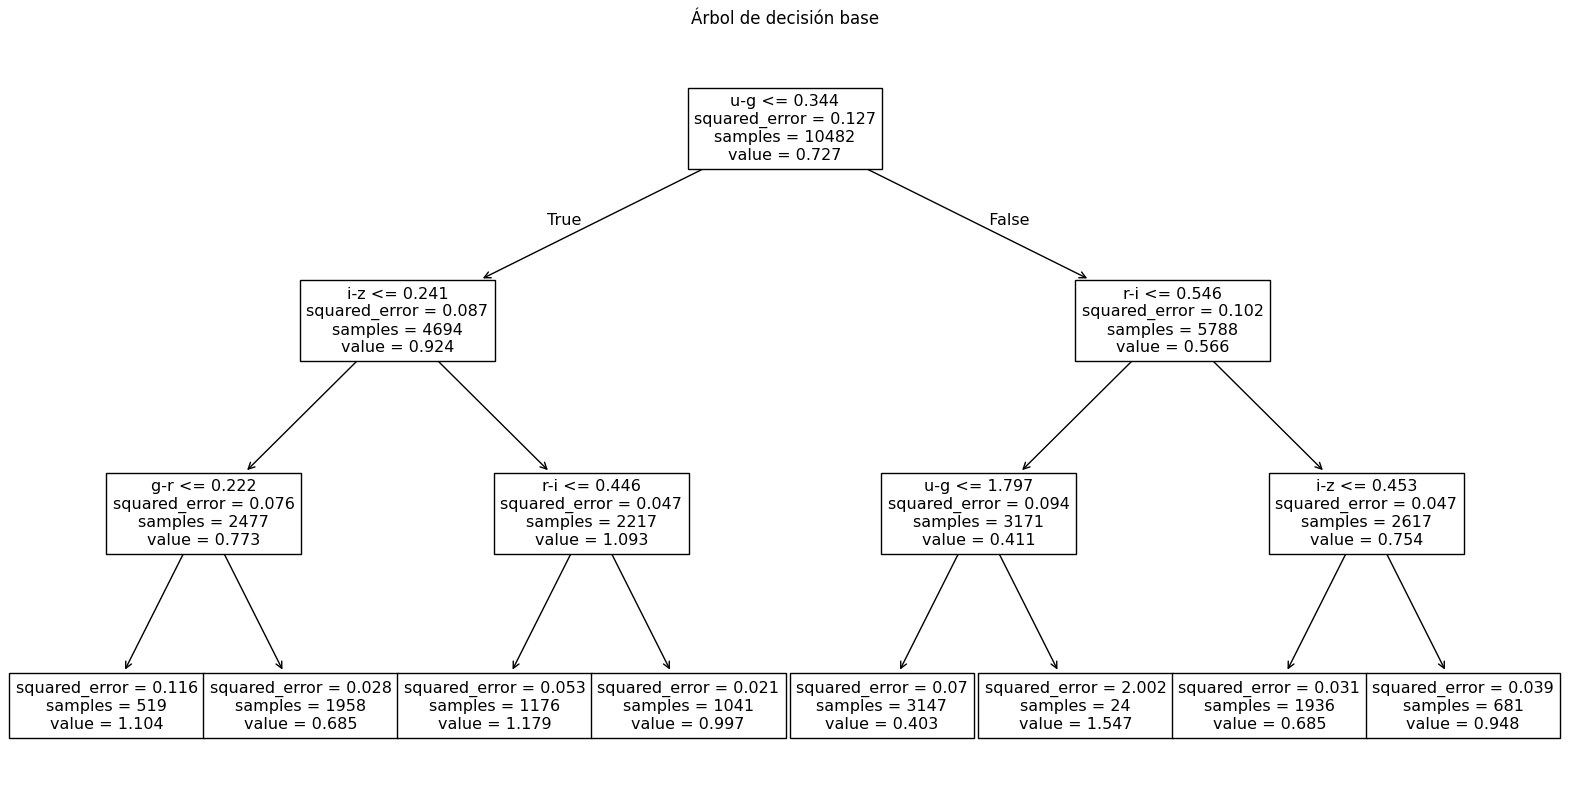

In [13]:
#Podemos ver una representación previa del Árbol de Decisión base

plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=features
)

plt.title("Árbol de decisión base")
plt.show()

## 6. Entrenamiento de algún método de ensamble, donde usaremos los métodos:
- `RandomForestRegressor`
- `ExtraTreesRegressor`
- `GradientBoostingRegressor`
- `HistGradientBoostingRegressor``

Para hacer del rango de análisis mucho más amplio y así obtener el que mejores resultados ofrezca.

In [14]:
#Probaremos los cuatro métodos sugeridos para poder compararlos después.

#Creamos una lista que comienza con los resultados iniciales del DecisionTree para expandirse
#en base a los resultados de los otros modelos
resultado_inicial = [dict(model="DecisionTree", mse_val=mse_val, nmad_val=nmad_val, eta_val=eta_val)]

models_pass1 = {
    "RandomForest": (RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=1), x_train_imp, x_val_imp),
    "ExtraTrees": (ExtraTreesRegressor(n_estimators=150, random_state=42, n_jobs=1), x_train_imp, x_val_imp),
    "GradientBoosting": (GradientBoostingRegressor(random_state=42), x_train_imp, x_val_imp),
    "HistGB_imputado": (HistGradientBoostingRegressor(random_state=42), x_train_imp, x_val_imp),
    "HistGB_NaN_nativo": (HistGradientBoostingRegressor(random_state=42), x_train, x_val),
}

#Aquí creamos el ciclo odnde se añadirán los resultados con las métricas de cada modelo
for name, (model, xtr, xv) in models_pass1.items():
    model.fit(xtr, y_train)
    pv = model.predict(xv)
    mv, nv, ev = photoz_metrics(y_val, pv)
    resultado_inicial.append(dict(model=name, mse_val=mv, nmad_val=nv, eta_val=ev))

res1 = pd.DataFrame(resultado_inicial).sort_values("mse_val").reset_index(drop=True)
res1

,model,mse_val,nmad_val,eta_val
0,ExtraTrees,0.023105,0.023086,0.038535
1,RandomForest,0.024370,0.022715,0.042350
2,HistGB_imputado,0.024638,0.030240,0.046166
3,HistGB_NaN_nativo,0.025013,0.030802,0.048073
4,GradientBoosting,0.027049,0.041125,0.058375
5,DecisionTree,0.053428,0.089340,0.152995


## 7. Optimización de hiperparámetros (puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc)

La tabla anterior nos muestra que todos los métodos de _ensamble_ superan al árbol individial. Entre ellos, los que destacan por menor MSE y NMAD son `ExtraTreesRegressor` y `RandomForestRegressor`. El que queda en peor posición, aparte de `DecisionTree` es `GradientBoostingRegressor`, debido a que este modelo es mucho más sensible a los hiperparámetros que los otros.

Optimizamos dos candidatos: `ExtraTreesRegressor` por su mejor resultado en MSE y `HistGradientBoostingRegressor` por su menor costo computacional en comparación a `RandomForestRegressor`.

Para la optimización, escogemos el método de RandomizedSearchCV debido a que podemos hacer solo 20 iteraciones al azar, en comparación con GridSearchCV que prueba con todas las combinaciones posibles y es computacionalmente caro.

In [15]:
#Nos interesa minimizar los scores
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

#Para una optimización más rápida, utilizamos los datos sin imputar y escogemos los rangos estimados
hgb_param_dist = {
    "max_iter": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.08, 0.11, 0.15],
    "max_leaf_nodes": [15, 30, 60, 130],
    "min_samples_leaf": [5, 10, 20, 30, 50],
    "l2_regularization": [0, 0.1, 0.5, 1.0],
    "max_depth": [None, 4, 6, 8], #Donde None representa sín límite en max_depth
}

cv4 = KFold(n_splits=3, shuffle=True, random_state=42)
hgb_search = RandomizedSearchCV(HistGradientBoostingRegressor(random_state=42), hgb_param_dist,
                                n_iter=20, cv=cv4, scoring=mse_scorer, random_state=42, n_jobs=1)
hgb_search.fit(x_train, y_train)
print("Mejores hiperparámetros para HistGB:", hgb_search.best_params_)
print("MSE CV:", -hgb_search.best_score_)

best_hgb = hgb_search.best_estimator_
mse_val_hgb, nmad_val_hgb, eta_val_hgb = photoz_metrics(y_val, best_hgb.predict(x_val))
print(f"MSE val: {mse_val_hgb:.5f}, NMAD val: {nmad_val_hgb:.5f}, eta val: {eta_val_hgb:.4f}")

Mejores hiperparámetros para HistGB: {'min_samples_leaf': 5, 'max_leaf_nodes': 60, 'max_iter': 200, 'max_depth': 8, 'learning_rate': 0.05, 'l2_regularization': 1.0}
MSE CV: 0.026539824229058182
MSE val: 0.02530, NMAD val: 0.02693, eta val: 0.0416


In [16]:
#Ahora trabajamos con ExtraTreesRegression
et_param_dist = {
    "n_estimators": [150],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_leaf": [1, 2, 4, 8, 12],
    "min_samples_split": [2, 5, 10],
    "max_features": [0.5, 0.7, 1.0, "sqrt"],
}
et_search = RandomizedSearchCV(ExtraTreesRegressor(random_state=42, n_jobs=1), et_param_dist,
                                n_iter=8, cv=3, scoring=mse_scorer, random_state=42, n_jobs=1)
et_search.fit(x_train_imp, y_train)
print("Mejores hiperparámetros para ExtraTrees (búsqueda con 150 árboles):", et_search.best_params_)
print("MSE CV:", -et_search.best_score_)

Mejores hiperparámetros para ExtraTrees (búsqueda con 150 árboles): {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20}
MSE CV: 0.026461206757477512


In [17]:
#Aquí reentrenamos el árbol reutilizando los mejores hiperparámetros encontrados en la búsqueda anterior, aumentando
#a 250 árboles para mejorar la predicción y activando OOB ya que queremos calcularlo sin necesariamente usar validación cruzada extra.
et_final_params = dict(et_search.best_params_)
et_final_params["n_estimators"] = 250
best_et = ExtraTreesRegressor(random_state=42, n_jobs=1, bootstrap=True, oob_score=True, **et_final_params)
best_et.fit(x_train_imp, y_train)

mse_val_et, nmad_val_et, eta_val_et = photoz_metrics(y_val, best_et.predict(x_val))
print(f"ExtraTrees mejorado; MSE val: {mse_val_et:.5f}, NMAD val: {nmad_val_et:.5f}, eta val: {eta_val_et:.4f}")
print("ExtraTrees OOB R2:", best_et.oob_score_)

ExtraTrees mejorado; MSE val: 0.02326, NMAD val: 0.02520, eta val: 0.0404
ExtraTrees OOB R2: 0.7918413779636939


Para el análisis de errores utilizamos OOB score y validación cruzada (una forma de comparar la versión rápida y otra calculada para el error estimado).
Podemos calcular out-of-bag $R^2$ de forma "gratuita" gracias al bootstrap de `ExtraTreesRegressor`. Esto lo compararemos con una validación cruzada de k-fold 4 para el mismo conjunto.

In [18]:
var_y_train = np.var(y_train)
cv5 = KFold(n_splits=4, shuffle=True, random_state=42)

print(f"OOB R^2: {best_et.oob_score_:.3f}")

cv_r2_scores = cross_val_score(best_et, x_train_imp, y_train, cv=cv5, scoring="r2")
print(f"Cross-validation R^2 (4-fold): {np.mean(cv_r2_scores):.3f}")

OOB R^2: 0.792
Cross-validation R^2 (4-fold): 0.790


## 8. Comparación de modelos usando MSE.

Interpretando los resultados, notamos que ambos están en un rango relativamente estrecho, lo que sugiere que OOB es una estimación bastante razonable para el dataset con el que estamos trabajando.

Ahora, vamos a "reentrenar" cada método con los mejores hiperparámetros encontrados, para armar la tabla requerida.

In [19]:
#Finalmente, comparamos los modelos obtenidos después de mejorar los parámetros
rf_final = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1)
rf_final.fit(x_train_imp, y_train)

gb_final = GradientBoostingRegressor(random_state=42, n_estimators=200, max_depth=3, learning_rate=0.05)
gb_final.fit(x_train_imp, y_train)

#Creamos una lista para guardar los resultados de los parámetros de cada modelo que hemos usado
rows = []

#Decision Tree (baseline)
mtr_dt, ntr_dt, etr_dt = photoz_metrics(y_train, model_tree.predict(x_train_imp))
mv_dt, nv_dt, ev_dt = photoz_metrics(y_val, model_tree.predict(x_val_imp))
rows.append(dict(Modelo="Decision Tree (baseline)", Features=f"{len(features)} (mag+color+missing)", Hiperparametros="max_depth=8, min_samples_leaf=10",
                  MSE_train=round(mtr_dt,5), MSE_val=round(mv_dt,5), NMAD_val=round(nv_dt,5), eta_val=round(ev_dt,4)))

#Random Forest
mtr_rf, ntr_rf, etr_rf = photoz_metrics(y_train, rf_final.predict(x_train_imp))
mv_rf, nv_rf, ev_rf = photoz_metrics(y_val, rf_final.predict(x_val_imp))
rows.append(dict(Modelo="Random Forest", Features=f"{len(features)}", Hiperparametros="n_estimators=300",
                  MSE_train=round(mtr_rf,5), MSE_val=round(mv_rf,5), NMAD_val=round(nv_rf,5), eta_val=round(ev_rf,4)))

#Gradient Boosting
mtr_gb, ntr_gb, etr_gb = photoz_metrics(y_train, gb_final.predict(x_train_imp))
mv_gb, nv_gb, ev_gb = photoz_metrics(y_val, gb_final.predict(x_val_imp))
rows.append(dict(Modelo="Gradient Boosting", Features=f"{len(features)}", Hiperparametros="n_estimators=200, depth=3, lr=0.05",
                  MSE_train=round(mtr_gb,5), MSE_val=round(mv_gb,5), NMAD_val=round(nv_gb,5), eta_val=round(ev_gb,4)))

#HistGradientBoosting (mejorado)
mtr_hgb, ntr_hgb, etr_hgb = photoz_metrics(y_train, best_hgb.predict(x_train))
mv_hgb, nv_hgb, ev_hgb = photoz_metrics(y_val, best_hgb.predict(x_val))
rows.append(dict(Modelo="HistGradientBoosting (mejorado)", Features=f"{len(features)} (NaN nativo)", Hiperparametros=str(hgb_search.best_params_),
                  MSE_train=round(mtr_hgb,5), MSE_val=round(mv_hgb,5), NMAD_val=round(nv_hgb,5), eta_val=round(ev_hgb,4)))

#Extra Trees (mejorado)
mtr_et, ntr_et, etr_et = photoz_metrics(y_train, best_et.predict(x_train_imp))
mv_et, nv_et, ev_et = photoz_metrics(y_val, best_et.predict(x_val_imp))
rows.append(dict(Modelo="Extra Trees (mejorado)", Features=f"{len(features)}", Hiperparametros=str(et_final_params),
                  MSE_train=round(mtr_et,5), MSE_val=round(mv_et,5), NMAD_val=round(nv_et,5), eta_val=round(ev_et,4)))


summary_table = pd.DataFrame(rows).sort_values("MSE_val").reset_index(drop=True)
summary_table

,Modelo,Features,Hiperparametros,MSE_train,MSE_val,NMAD_val,eta_val
0,Extra Trees (mejorado),17,"{'n_estimators': 250, 'min_samples_split': 5, ...",0.00816,0.02327,0.02524,0.0404
1,Random Forest,17,n_estimators=300,0.00361,0.02459,0.02226,0.0420
2,HistGradientBoosting (mejorado),17 (NaN nativo),"{'min_samples_leaf': 5, 'max_leaf_nodes': 60, ...",0.00885,0.02530,0.02693,0.0416
3,Gradient Boosting,17,"n_estimators=200, depth=3, lr=0.05",0.02101,0.02574,0.04225,0.0595
4,Decision Tree (baseline),17 (mag+color+missing),"max_depth=8, min_samples_leaf=10",0.05306,0.05343,0.08934,0.1530


## 9. Selección del modelo final.

Analizando la tabla de arriba es que notamos que el modelo que mejor se comporta con los datos es `ExtraTreesRegressor` mejorado, ya que tiene el menor MSE de validación entre todos los otros modelos, además de una tasa de outliers y un NMAD decente.

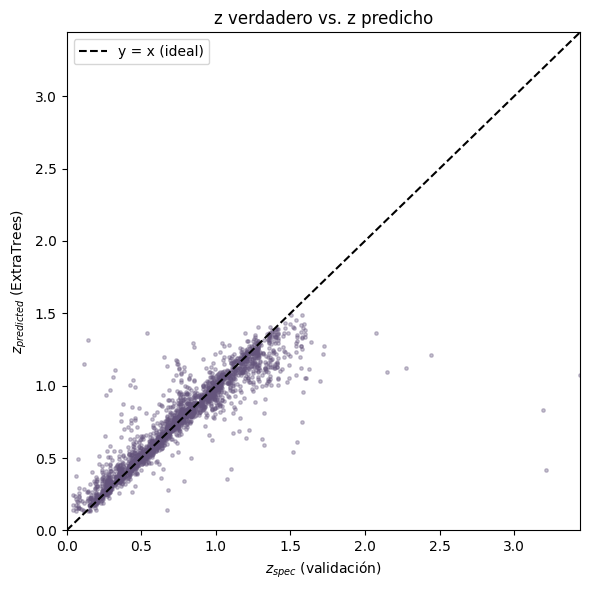

In [20]:
pred_val_final = best_et.predict(x_val_imp)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_val, pred_val_final, s=6, alpha=0.35, color="#64547c")
lims = [0, max(y_val.max(), pred_val_final.max())]
ax.plot(lims, lims, "--", lw=1.5, label="y = x (ideal)", color="black")
ax.set_xlabel(r"$z_{spec}$ (validación)")
ax.set_ylabel(r"$z_{predicted}$ (ExtraTrees)")
ax.set_title("z verdadero vs. z predicho")
ax.legend(); ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout(); plt.show()

Podemos notar en el gráfico de scatter que compara $z_{spectroscopic} \text{ vs } z_{predicted}$ que sigue de forma razonable la línea 1:1 mientras nos mantengamos bajo el rango de z~1.2 (posiblemente a que sea una zona con mayores datos de galaxias). Tambien notamos que sobre este punto empieza a haber una gran dispersión por debajo de la línea. Este efecto se analiza con más detalle en la sección de Preguntas de análisis final.

Generamos gráficos comparativos:
- Residuos vs. redshift
- Error por rango de redshift
Para mejorar el análisis que respecta a las preguntas finales.

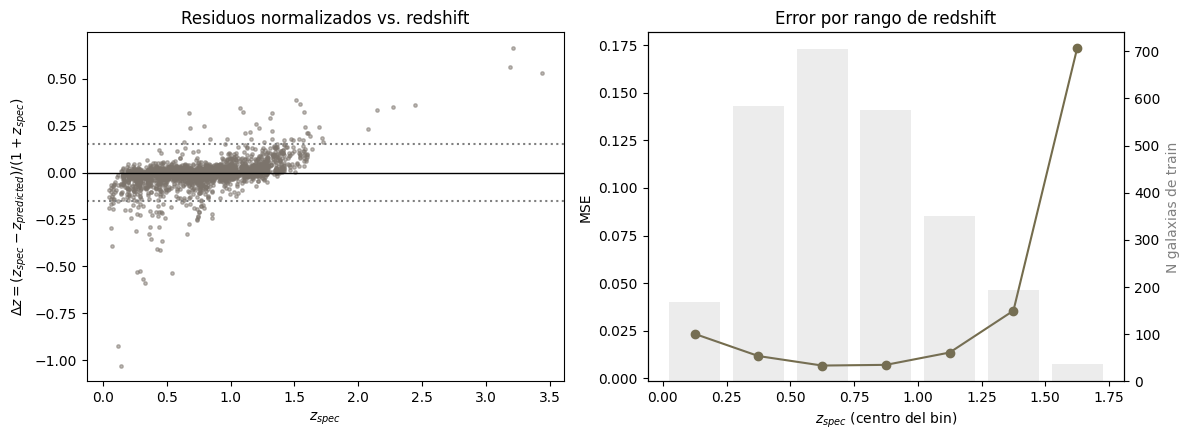

,z_bin_center,mse,nmad,n_val
0,0.125,0.023330,0.048930,168
1,0.375,0.011668,0.025994,585
2,0.625,0.006674,0.017122,705
3,0.875,0.007043,0.023476,575
4,1.125,0.013527,0.030766,351
5,1.375,0.035513,0.050052,193
6,1.625,0.173480,0.061221,37


In [21]:
dz = (y_val.values - pred_val_final) / (1 + y_val.values)
bins = np.linspace(0, 3, 13)
bin_idx = np.digitize(y_val.values, bins)
bin_centers, bin_mse, bin_nmad, bin_n = [], [], [], []
for b in range(1, len(bins)):
    m = bin_idx == b
    if m.sum() < 5:
        continue
    bin_centers.append((bins[b-1]+bins[b])/2)
    bin_mse.append(mean_squared_error(y_val.values[m], pred_val_final[m]))
    ddz = dz[m]
    bin_nmad.append(1.48*np.median(np.abs(ddz - np.median(ddz))))
    bin_n.append(m.sum())

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].scatter(y_val, dz, s=6, alpha=0.5, color="#7c746c")
axes[0].axhline(0, color="k", lw=1)
axes[0].axhline(0.15, color="gray", ls=":")
axes[0].axhline(-0.15, color="gray", ls=":")
axes[0].set_xlabel(r"$z_{spec}$"); axes[0].set_ylabel(r"$\Delta z=(z_{spec}-z_{predicted})/(1+z_{spec})$")
axes[0].set_title("Residuos normalizados vs. redshift")

ax2 = axes[1]
ax2.plot(bin_centers, bin_mse, "o-", color="#746c4c")
ax2.set_xlabel(r"$z_{spec}$ (centro del bin)")
ax2.set_ylabel("MSE")
ax2.tick_params(axis="y")
ax3 = ax2.twinx()
ax3.bar(bin_centers, bin_n, width=0.2, alpha=0.15, color="gray")
ax3.set_ylabel("N galaxias de train", color="gray")
ax2.set_title("Error por rango de redshift")
plt.tight_layout()
plt.show()

pd.DataFrame({"z_bin_center": bin_centers, "mse": bin_mse, "nmad": bin_nmad, "n_val": bin_n})

## 10. Generación de predicciones para ```test_redshift.csv```

Ahora, antes de generar las predicciones finales, podemos ver las Features Importance para analizar cuales bandas resultan las más importantes/con mayores datos relevantes.
Además, graficamos también las Permutation Importance, el cuál fue evaluado en el set de validación que no había participado en el entrenamiento.

Esto nos será util para responder el análisis final.

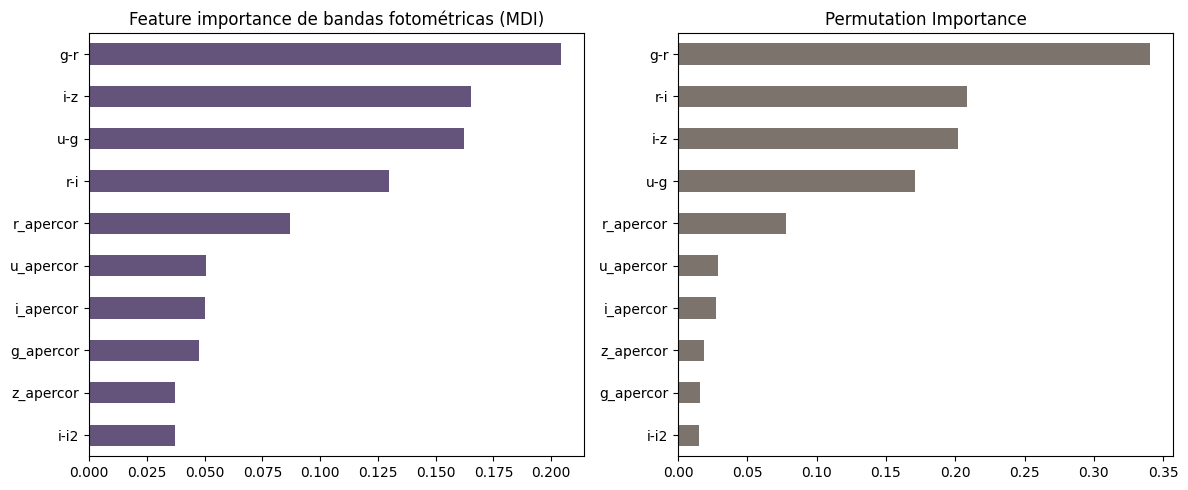

,MDI,Permutation
g-r,0.204002,0.340152
g_apercor,0.047595,0.015931
g_apercor_missing,0.000046,0.000000
i-i2,0.037104,0.015213
i-z,0.165424,0.201651
i2_apercor,0.020717,0.006830
i2_apercor_missing,0.007945,0.005806
i_apercor,0.050099,0.027352
i_apercor_missing,0.000030,-0.000011
r-i,0.129641,0.208335


In [22]:
mdi = pd.Series(best_et.feature_importances_, index=features).sort_values(ascending=False)
perm = permutation_importance(best_et, x_val_imp, y_val, n_repeats=8, random_state=42, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
mdi.head(10).iloc[::-1].plot(kind="barh", ax=axes[0], color="#64547c")
axes[0].set_title("Feature importance de bandas fotométricas (MDI)")
perm_imp.head(10).iloc[::-1].plot(kind='barh', ax=axes[1], color="#7c746c")
axes[1].set_title("Permutation Importance")
plt.tight_layout(); plt.show()

pd.DataFrame({"MDI": mdi, "Permutation": perm_imp}).head(10)

Finalmente, terminamos por reentrenar el modelo final, que es `ExtraTreesRegressor` con los hiperparámetros optimizados utilizando el todo el set de entrenamiento limpio (es decir, entrenamiento y validación) y generamos las predicciones para generar el dataset `test_redshift.csv`

In [23]:
imputer_full = SimpleImputer(strategy="median")
X_full_imp = pd.DataFrame(imputer_full.fit_transform(x), columns=features, index=x.index)
X_test_imp = pd.DataFrame(imputer_full.transform(data_test[features]), columns=features, index=data_test.index)

final_model = ExtraTreesRegressor(random_state=42, n_jobs=1, bootstrap=True, oob_score=True, **et_final_params)
final_model.fit(X_full_imp, y)
print("OOB R2:", final_model.oob_score_)

test_pred = final_model.predict(X_test_imp)
test_pred = np.clip(test_pred, 0, None)

predicciones = pd.DataFrame({"objno_deep2": data_test["objno_deep2"], "z_pred": test_pred})
predicciones.to_csv("predicciones.csv", index=False)
print("Las predicciones están guardadas:", predicciones.shape)
predicciones.head()

OOB R2: 0.7982242090068785
Las predicciones están guardadas: (4765, 2)


,objno_deep2,z_pred
0,12011416,0.559743
1,12023279,0.821611
2,13017399,1.001996
3,12008131,0.458291
4,12003729,0.543175


# Preguntas de análisis final.

### Comparación de modelos:
1. ¿Qué modelo obtuvo el menor MSE en validación?

    El modelo `ExtraTreesRegressor` mejorado obtuvo un MSE de validación de aproximadamente 0.02327, el cual es levemente mejor que `RandomForestRegressor`, de un MSE de 0.02437. En tercer puesto queda `HistGradientBoosting` mejorado con un MSE de 0.02530.
    
    Toda esta información podemos verla en la tabla de resultados de la sección 8.

2. ¿Ese modelo fue elegido como modelo final?

    Sí, se escogió `ExtraTreesRegressor` ya que fue el que tuvo mejor rendimiento con respecto a las métricas analizadas (MSE, NMAD y eta), siendo consistentemente el más bajo tanto con los parámetros por defecto como con los parámetros optimizados. Cabe destacar que los segundos mejores resultados en general fueron `RandomForestRegressor` (con mejor NMAD) y `HistGradientBoosting` (con mejor desempeño computacional), pero se escogió el que minimizase MSE principalmente.

3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

    Principalmente, que el árbol individual tuvo peor desempeño en las métricas analizadas, esto posiblemente a que es un modelo de alta varianza y que no logra generalizar bien hacia datos nuevos, memorizando el set de entrenamiento. En contraste, los ensamble promedian varios árboles, lo que reduce bastante el MSE. Confirman la reducción de varianza por _bagging_ o por _boosting_.

### Variables:
4. ¿Qué variables parecen ser más importantes para predecir el redshift?

    Los colores `g-r`, `i-z`, `u-g` y `r-i` son los que destacan por encima de cualquier magnitud individual, esto según ambos criterios de importancia que graficamos en la sección 10.

5. Calculen la importancia de variables con al menos dos criterios distintos (MDI y Permutation Importance). ¿Coinciden en el ranking? Si no coinciden, ¿a que atribuyen la diferencia?

    Los resultados visibles entre MDI y Permutation Importance efectivamente coinciden, donde los primeros cuatro coinciden con el mismo criterio (`g-r`, `i-z`, `u-g`, `r-i`). Aún así, cambia el orden entre `i-z` y `r_i` entre ambos gráficos. Esta diferencia posiblemente se debe a que MDI calcula directamente la importancia durante el entrenamiento y favorece los que mejores resultados dá en comparación con Permutation Importance, que mide de forma más directa cuánto "empeora" el error del modelo ya entrenado.



### Errores del modelo:
6. ¿En qué rangos de redshift falla más el modelo?

    El modelo falla visiblemente (analizando el gráfico de "Error por rango de redshift" de la sección 9) cuando $z \geq 1.3$, ya que el MSE por bin crece de forma muy notoria.

7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$ vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?

    Es posible observar este efecto en el gráfico de la misma sección 9(z verdadero vs z predicho), donde de forma parcial los puntos donde $z_{spec} \geq 1.3$ caen por debajo de la línea 1:1 (hay gran dispersión), lo que implica una subestimación. Si analizamos también el gráfico de barras, notaremos que en este rango es donde menos datos de ejemplo hay, esto debido a que el modelo no tiene suficiente cantidad de datos y sus predicciones tienden más a la media general.

8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

    Analizando los resultados de la sección 7, obtenemos que los valores son de:
    - OOB $\simeq$ 0.792
    - Cross-Validation $\simeq$ 0.790
    Ambos son bastante consistentes y se mantienen en un rango bastante similar, sin grandes discrepancias. Esto se puede interpretar como que para este dataset de tamaño razonable, el OOB score es una estimación bastante confiable del error de generalización, de forma que se puede usar "gratuitamente" y sin tener que darle carga extra computacional al programa que hace una validación cruzada más compleja.

### Proceso:
9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?

    Si analizamos los filtros iniciales que aplicamos, `zquality` puede ser causante de uno de estos sesgos. Esto ya que estamos entregandole al modelo las galaxias con la mejor espectroscopía, que no necesariamente representan todos los resultados del catálogo.
    Esto también se puede ver en la parte de "estrechamiento" del redshift, causado por un sesgo debido a los pocos datos de entrenamiento para esa región.

10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?

    La parte que más afecta el resultado es la creación de features (colores). Al principio, cuando se probó el modelo inicial sin ellos, su error era gigante en el MSE y con los features bajó de un ~0.7 a un ~0.2, además así es posible separar los rangos de colores de las magnitudes individuales que es notable en el gráfico de Features Importance.

11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico?

    No necesariamente. En este caso, tanto `ExtraTreesRegressor` era tan competente como `RandomForestRegressor`, ya que ambos compartían los menores MSE, y es importante considerar que RF obtuvo mejor NMAD, lo cual puede representar mejor manejo frente a errores más grandes. Esto puede ser incluso más relevante que minimizar solamente el MSE ya que esta métrica penaliza con mayor peso los errores grandes (porque eleva al cuadrado).
    La elección del modelo dependerá de que es más necesario, si un modelo sensible a errores puntuales o una generalización más amplia.

### Conclusión:

  El modelo final con el que se trabajó fue `ExtraTreesRegressor` con los parámetros `bootstrap=True`, `max_depth=20`, `max_features=0.7`, `min_samples_split=5` y `min_samples_leaf=1`. Fue entrenado con 17 variables (features de 6 magnitudes, 5 colores y 6 de banda faltante) y fue el que obtuvo menor MSE de validación y valores de $\sigma$NMAD y $\eta$ competitivos con respecto a los otros modelos de ensemble.
  
  Nuestros candidatos siguientes fueron `RandomForestRegressor` (debido a un buen desempeño con MSE y una mejora notable de $\sigma$NMAD) y `HistGradientBoostingRegressor` (con un desempeño bastante similar pero más rápido que los anteriores).